# Домашнее задание 6. Подключение очереди и асинхронной обработки

In [1]:
# %%capture
# import warnings
# warnings.filterwarnings('ignore', category=DeprecationWarning)
# !apt-get update -y >/dev/null
# !curl -fsSL https://deb.nodesource.com/setup_22.x | sudo -E bash -
# !apt install nodejs -y
# !apt-get install -y npm  >/dev/null
# !npm install -g npm@11.7.0
# !npm install -g pnpm
# !rm -rf studio
# !git clone https://github.com/asyncapi/studio.git
print('делаем локально')


In [2]:
# from google.colab import userdata
# import os
# os.environ["tunatoken"] = userdata.get('tuna')
# !curl -sSLf https://get.tuna.am | sh >/dev/null
# !tuna config save-token $tunatoken
print('делаем локально')


## 1. Оценить необходимость асинхронной обработки

* Параллелизм данных — это одновременное выполнение на нескольких ядрах одной и той же функции в разных элементах набора данных (он же SIMD, single-instruiction-multiple-data).

    *В [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) код был неоптимальный, поскольку при наличии вычислительных мощностей можно выполнять заблюривание каждого кадра **одновременно.***


* Параллелизм задач — это одновременное выполнение на нескольких ядрах множества различных функций в одном и том же или разных наборах данных.

    *Если бы мы в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd) распараллелили данные, то могли бы выполнять заблюривание каждого кадра **асинхронно**, по цепочке gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect*

Асинхронный код писать сложнее, но сегодня он является основой всех серверов в машинном обучении. Напишите в ячейке ниже свою оценку выигрыша (можно методом HDD) от асинхронной обработки конвейера ML в [предыдущем домашнем задании](https://colab.research.google.com/drive/1rhDmTDaI4yyrCUnCqj-juPrxgW61MAxT?usp=sharing#scrollTo=7d91f4cd).


*Ожидаемый артефакт: код в [ячейке](#scrollTo=1JM7AcPIaERg)*


In [3]:
N = 100
t1, t2, t3 = 0.01, 0.05, 0.02
seq = N * (t1 + t2 + t3)
asy = N * max(t1, t2, t3) + (t1 + t2)
print(round(seq, 2), round(asy, 2), round(seq / asy, 2))


Прикинул - 100 кадров, стадии gray/detect/mosaic ≈ 10/50/20 мс на кадр. Последовательно — 8 секунд. В пайплайне (3 стадии параллельно) лимитирует самая медленная дает на детект 50 мс — итого примерно 5 секунд. Ускорение на 1.6 на ровном месте. На реальном сервисе с GPU и батчами разница ещё больше.

## 2. Выбрать брокер очередей, спроектировать асинхронный API для модели

* Обоснуйте свой выбор брокера (Redis/Kafka/RabbitMQ) для асинхронной обработки конвейера ML.
* Создайте цепочку из 3 событий gray = cv2.cvtColor(frame) -> faces = face_cascade.detectMultiScale(gray) -> apply_mosaic_effect и опишите цепочку в формате AsyncApi.
* Полученное описание скопируйте или скачайте, как показано на рисунке, и вставьте в этот блокнот в ячейку ниже.

**Выбор брокера: RabbitMQ.** Для ML-конвейера с цепочкой gray - faces - mosaic нужен брокер с роутингом и подтверждениями. Kafka — это про событийный лог. Redis быстрый но без гарантий что событие дошло. RabbitMQ умеет в очереди с ack, exchange'ы и роутинг по ключам — то что нужно для пайплайна.

%%html
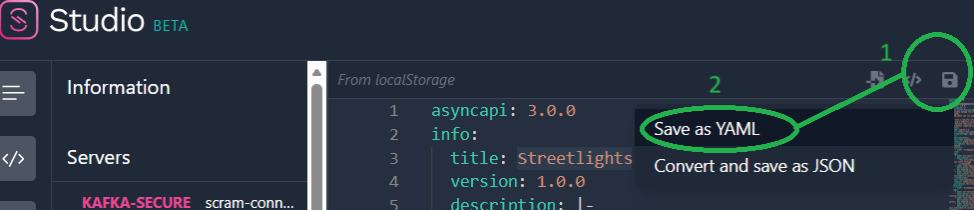

In [4]:
# %cd studio
# !pnpm install  >/dev/null
# !echo "Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter"
# !sleep 15 & pnpm run studio & tuna http 8000 & wait

# для colab. локально подними studio через docker-compose из ячейки ниже


Если не получилось запустить из блокнота, то можно **на локальной машине** поднять контейнер, скопировав docker-compose.yaml
```yaml
name: project_asyncapi_studio
services:
    studio:
        ports:
            - 8000:80
        image: asyncapi/studio
```


*Ожидаемый артефакт: YAML в [ячейке](#scrollTo=aBYphRLZ3x4H)*


In [5]:
%%writefile async.yaml
# вставьте описание сервиса в формате AsyncApi
asyncapi: 2.6.0
info:
  title: ML Mosaic Pipeline
  version: '0.1.0'
  description: gray -> faces -> mosaic
servers:
  rabbit:
    url: amqp://localhost:5672
    protocol: amqp
channels:
  frame.gray:
    publish:
      message:
        $ref: '#/components/messages/Frame'
  frame.faces:
    publish:
      message:
        $ref: '#/components/messages/Faces'
  frame.mosaic:
    publish:
      message:
        $ref: '#/components/messages/Mosaic'
components:
  messages:
    Frame:
      payload:
        type: object
        properties:
          id: {type: string}
          gray: {type: string}
    Faces:
      payload:
        type: object
        properties:
          id: {type: string}
          boxes: {type: array}
    Mosaic:
      payload:
        type: object
        properties:
          id: {type: string}
          frame: {type: string}


Overwriting async.yaml


## 3. Выбрать стратегию (паттерн) загрузки моделей и реализовать ее

Вспомните [семинар](https://colab.research.google.com/drive/1MeNdQ0F_o4T85HKUQoyA8lhB-QUYqP24?usp=sharing), выберите **одну** стратегию загрузки моделей и напишите код для загрузки [модели](https://huggingface.co/cointegrated/rubert-tiny2)

*Ожидаемый артефакт: код в [ячейке](#scrollTo=X5IFDgIr35O5)*

In [6]:
from IPython.display import display
import ipywidgets as widgets
select_widget = widgets.Select(
    options=['Eager','Lazy','Pool','Hot Reload'],
    value='Lazy',
    description='Паттерн:',
    disabled=False
)
display(select_widget)
def on_value_change(change):
    print(f"Опишите в ячейке выше, почему выбран паттерн '{change['new']}', и реализуйте его")
select_widget.observe(on_value_change, names='value')
description_widget = widgets.Textarea(
    value='',
    placeholder='Опишите здесь, почему выбран паттерн',
    description='Обоснование:',
    disabled=False,
    layout=widgets.Layout(height='100px', width='auto')
)
display(description_widget)

Select(description='Паттерн:', index=1, options=('Eager', 'Lazy', 'Pool', 'Hot Reload'), value='Lazy')

Textarea(value='', description='Обоснование:', layout=Layout(height='100px', width='auto'), placeholder='Опиши…

**Почему Lazy:** модель грузим только при первом вызове. Пока сервис простаивает память не займет. Подходит когда модель тяжёлая, но запросы идут редко.

In [7]:
# реализуйте паттерн здесь
# взял Lazy
from transformers import AutoTokenizer, AutoModel
import torch, time

NAME = 'cointegrated/rubert-tiny2'

class Lazy:
    def __init__(self):
        self.tok, self.m = None, None
    def _l(self):
        if self.tok is None:
            self.tok = AutoTokenizer.from_pretrained(NAME)
            self.m = AutoModel.from_pretrained(NAME)
    def emb(self, t):
        self._l()
        x = self.tok(t, return_tensors='pt')
        with torch.no_grad():
            return self.m(**x).last_hidden_state.mean(1).squeeze().numpy()

mod = Lazy()
print('m:', mod.m)
t0 = time.time(); v = mod.emb('привет'); print(round(time.time() - t0, 2), v.shape)
t0 = time.time(); mod.emb('ещё раз'); print(round(time.time() - t0, 2))


m: None
1.56 (312,)
0.0


## 4. Создать загрузку данных  батчами в модель

Вспомните паттерн батчинга (Batching) из раздаточных материалов модуля и реализуйте его при условии, что длина буфера превышает 64 элемента или время ожидания превысило 30 секунд
```python
if len(buffer) >= 32 or timeout_reached(30):
```


*Ожидаемый артефакт: код в [ячейке](#scrollTo=U1qbvPfICwEi)*

In [8]:
# 64 или 30 сек
import time

class B:
    def __init__(self):
        self.buf = []
        self.t0 = time.time()
    def add(self, x):
        self.buf.append(x)
        if len(self.buf) >= 64 or time.time() - self.t0 > 30:
            b, self.buf = self.buf, []
            self.t0 = time.time()
            return b
        return None

b = B()
out = []
for i in range(70):
    r = b.add(i)
    if r is not None:
        out.append(len(r))
print(out, len(b.buf))


[64] 6


Сделал батчер: собирает данные пока в буфере не наберётся 64 элемента или не пройдёт 30 секунд — что раньше. Когда условие срабатывает, отдаёт батч и сбрасывает таймер. 

## 5. Создать онлайн-загрузку данных в модель

Вспомните асинхронный ML-сервис на связке Celery + RabbitMQ из раздаточных материалов модуля и реализуйте онлайн-загрузку данных в модель с помощью любого брокера.



*Ожидаемый артефакт: код в [ячейке](#scrollTo=FZiukZtfaCAY)*

In [9]:
# беру asyncio.Queue чтобы сделать локально
# на сервере вместо него ставится celery+redis (код снизу, как было бы)

import asyncio
from transformers import AutoTokenizer, AutoModel
import torch

NAME = 'cointegrated/rubert-tiny2'
tok = AutoTokenizer.from_pretrained(NAME)
m = AutoModel.from_pretrained(NAME)

q = asyncio.Queue()

async def producer():
    # шлём тексты с задержкой — типа реальные онлайн-запросы
    for s in ['привет', 'онлайн запрос', 'ещё один']:
        await q.put(s)
        await asyncio.sleep(0.3)
    await q.put(None)  # маркер конца

async def worker():
    while True:
        s = await q.get()
        if s is None:
            break
        x = tok(s, return_tensors='pt')
        with torch.no_grad():
            v = m(**x).last_hidden_state.mean(1).squeeze().numpy()
        print(s, v.shape)

await asyncio.gather(producer(), worker())

привет (312,)
онлайн запрос (312,)
ещё один (312,)


[None, None]

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали о применимости асинхронной обработки в реальных проектах.



### Выводы

AsyncAPI лего пишется и валидируется в Studio.

Брокер — redis быстрее поднять чем реббит. 
Lazy подходит когда модель тяжёлая и ее редко вфзывают
Async для прода надо всегда делать иначе  — синхронный сервис с тяжёлой моделью под нагрузкой ляжет.